# 02 - Results walkthrough

Reads the tables produced by the full pipeline run.

In [1]:
import sys, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from supply_pipeline.config import load_config
cfg = load_config(ROOT / "config.toml")
p = cfg.paths
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
%matplotlib inline

## Backtest

In [2]:
t = p.tables_dir
display(pd.read_csv(t / "backtest_metrics_overall.csv").round(3))
display(pd.read_csv(t / "backtest_metrics_cluster.csv").pivot(index="cluster", columns="model", values="wape").round(3))
display(pd.read_csv(t / "model_selection.csv").round(3))

,model,n,wape,mape,bias,pinball,coverage_90,coverage_80,width_rel
0,ets,20912,0.204,0.636,-0.061,0.062,0.944,0.902,1.155
1,lgbm,20912,0.173,0.338,-0.048,0.053,0.734,0.581,0.497
2,ma4,20912,0.231,0.422,-0.075,0.068,0.931,0.871,1.262
3,seasonal_naive,20912,0.559,15.165,0.483,0.119,0.767,0.659,0.954


model,ets,lgbm,ma4,seasonal_naive
cluster,,,,
A-X,0.174,0.125,0.178,0.309
A-Y,0.196,0.165,0.220,0.603
A-Z,0.274,0.267,0.318,0.676
B-Y,0.176,0.151,0.234,0.245
B-Z,0.143,0.114,0.158,0.163
C-Z,0.225,0.137,0.235,0.737


,cluster,selected_model,wape_mean,wape_std,bias_mean,coverage_90,best_wape,rationale
0,A-X,lgbm,0.125,0.024,-0.031,0.781,0.125,lowest mean WAPE
1,A-Y,lgbm,0.168,0.063,-0.027,0.730,0.168,lowest mean WAPE
2,A-Z,lgbm,0.270,0.108,-0.112,0.706,0.270,lowest mean WAPE
3,B-Y,lgbm,0.145,0.072,-0.052,0.740,0.145,lowest mean WAPE
4,B-Z,lgbm,0.114,0.023,-0.039,0.754,0.114,lowest mean WAPE
5,C-Z,lgbm,0.144,0.071,-0.069,0.781,0.144,lowest mean WAPE


In [3]:
display(pd.read_csv(t / "backtest_metrics_holdout_calibrated_overall.csv").round(3))
display(pd.read_csv(t / "interval_calibration.csv").pivot(index=["model", "cluster"], columns="nominal", values="k").round(2))

,model,n,wape,mape,bias,pinball,coverage_90,coverage_80,width_rel
0,ets,7872,0.168,1.055,-0.057,0.044,0.891,0.789,0.822
1,lgbm,7872,0.130,0.346,-0.026,0.040,0.945,0.906,0.945
2,ma4,7872,0.218,0.494,-0.108,0.055,0.874,0.719,0.918
3,seasonal_naive,7872,0.533,16.010,0.424,0.104,0.952,0.830,1.476


nominal                  0.8   0.9
model          cluster            
ets            A-X     -0.19 -0.19
               A-Y     -0.23 -0.22
               A-Z     -0.01  0.00
               B-Y     -0.22 -0.18
               B-Z     -0.03 -0.00
               C-Z     -0.27 -0.24
lgbm           A-X      0.21  0.23
               A-Y      0.58  0.37
               A-Z      0.66  0.59
               B-Y      0.38  0.28
               B-Z      0.33  0.29
               C-Z      0.75  0.52
ma4            A-X     -0.16 -0.21
               A-Y     -0.23 -0.22
               A-Z     -0.01  0.00
               B-Y     -0.13 -0.11
               B-Z     -0.01  0.01
               C-Z     -0.28 -0.28
seasonal_naive A-X      0.32  0.28
               A-Y      0.15  0.19
               A-Z      0.30  0.47
               B-Y      0.19  0.22
               B-Z      0.27  0.35
               C-Z     -0.19 -0.17

## Figures

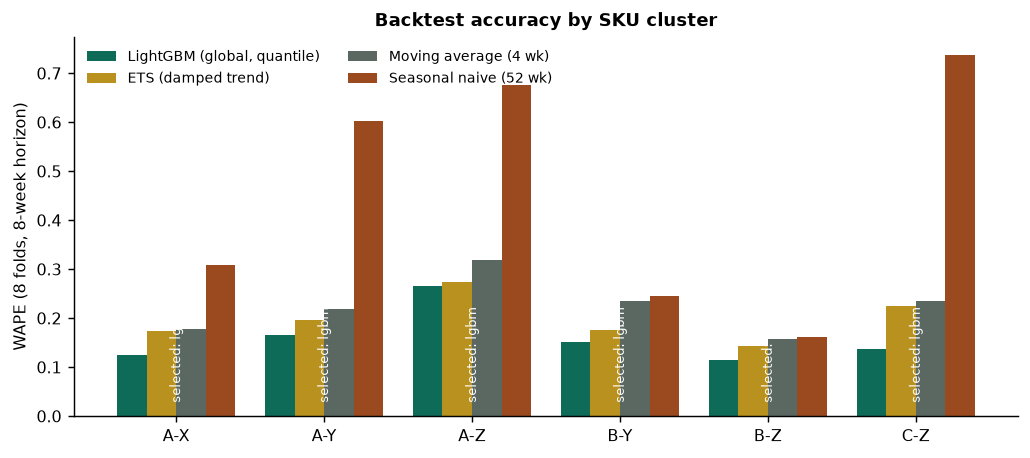

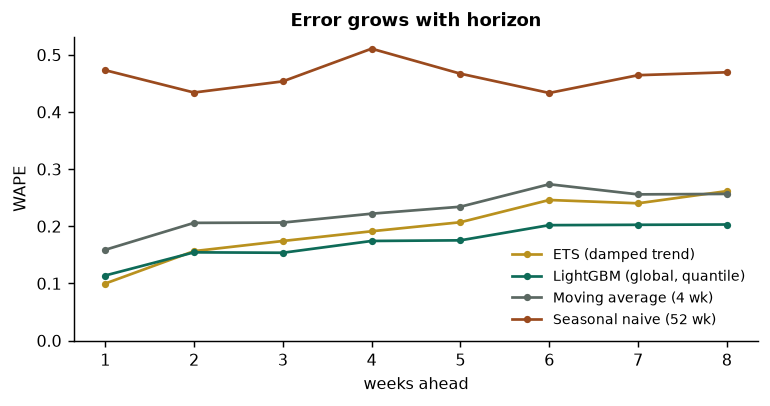

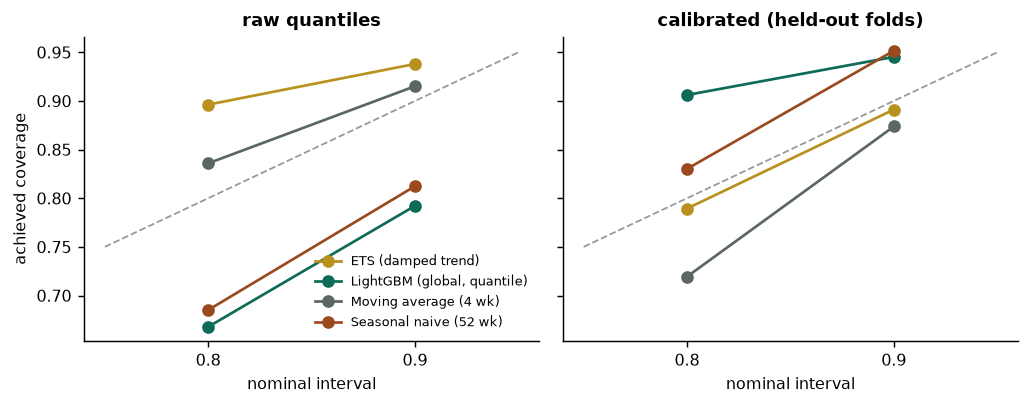

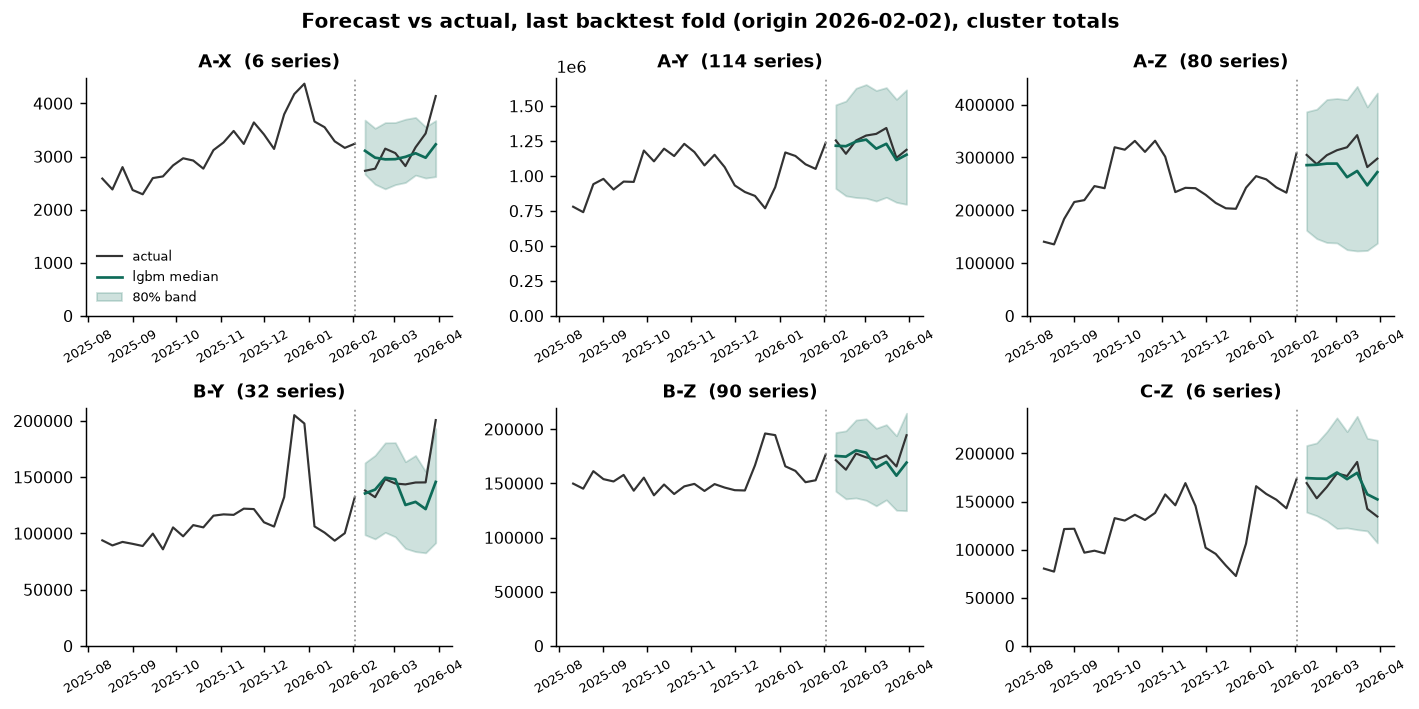

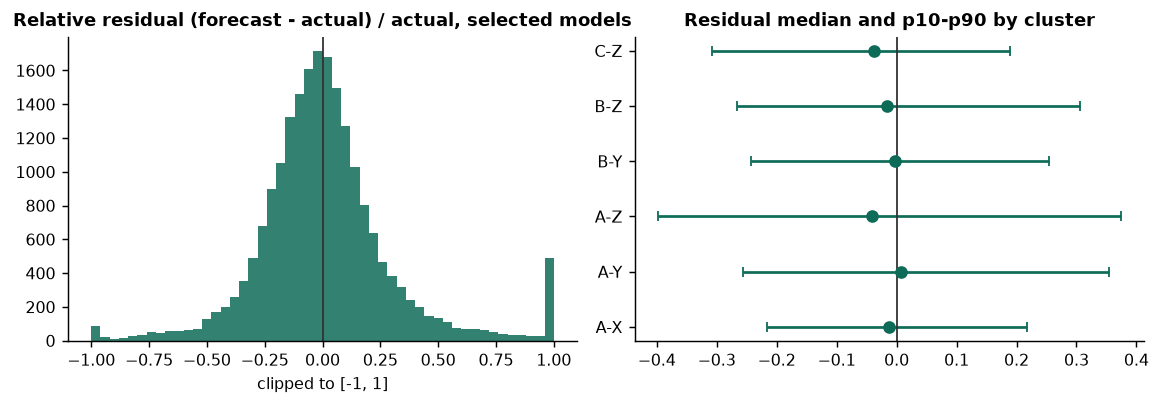

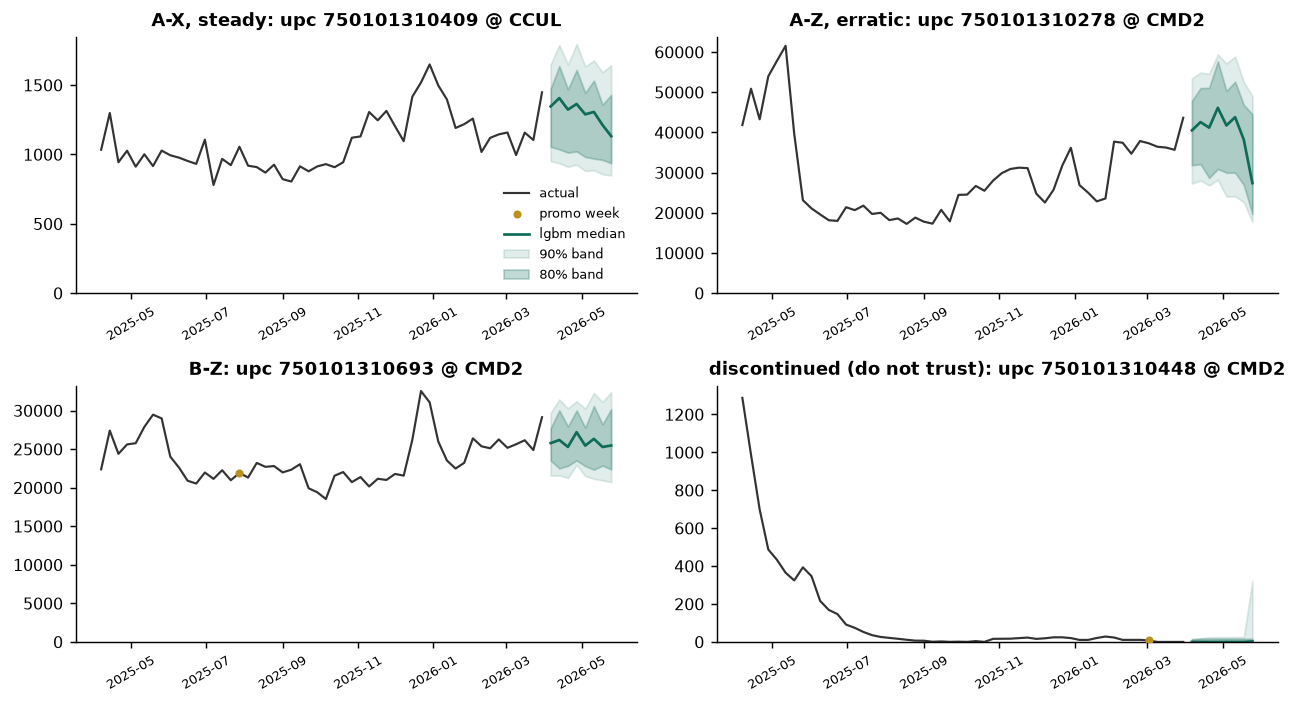

In [4]:
from IPython.display import Image, display as show
for name in ["model_comparison", "wape_by_horizon", "coverage_calibration", "cluster_forecast_vs_actual", "residuals", "series_examples"]:
    show(Image(filename=str(p.figures_dir / f"{name}.png")))

## Stock-out risk

,method,n,n_alerts,n_events,precision,recall,f1,false_alarm_rate,median_cover_at_alert
0,cover,2247,514,103,0.148,0.738,0.246,0.204,7.812
1,prob,2247,195,103,0.287,0.544,0.376,0.065,5.352
2,iforest,2247,80,103,0.388,0.301,0.339,0.023,6.507


,method,threshold,n,n_alerts,n_events,precision,recall,f1,false_alarm_rate
0,cover,3.0,2247,49,103,1.000,0.476,0.645,0.000
1,cover,5.0,2247,90,103,0.544,0.476,0.508,0.019
2,cover,7.0,2247,195,103,0.287,0.544,0.376,0.065
3,cover,10.0,2247,344,103,0.174,0.583,0.268,0.132
4,cover,14.0,2247,433,103,0.159,0.670,0.257,0.170
5,cover,21.0,2247,712,103,0.107,0.738,0.187,0.297
6,cover,28.0,2247,929,103,0.082,0.738,0.147,0.398
7,prob,0.1,2247,307,103,0.182,0.544,0.273,0.117
8,prob,0.2,2247,269,103,0.208,0.544,0.301,0.099
9,prob,0.3,2247,235,103,0.238,0.544,0.331,0.083


,method,n_onsets,n_onsets_alerted,median_lead_time_days
0,cover,1,0,NaN
1,prob,1,0,NaN
2,iforest,1,0,NaN


severity
none      238
medium     58
high       25
Name: count, dtype: int64


,upc,cedis,cluster,date,on_hand,stores_reporting,stockout_store_share,daily_mean_7d,demand_7d_p50,demand_7d_p90,cover_days,cover_threshold,p_stockout_7d,alert_cover,alert_prob,alert_iforest,iforest_score,severity
0,750101310055,CMD2,A-Z,2026-04-02,884.0,99,0.73,580.23,4061.59,5607.86,1.52,21,1.00,True,True,True,0.77,high
1,750101310553,CMD2,B-Z,2026-04-02,286.0,16,0.31,110.43,773.03,1031.56,2.59,21,1.00,True,True,False,0.54,high
2,750101310689,CMD2,B-Z,2026-04-02,4610.0,71,0.03,822.01,5754.09,6276.35,5.61,21,1.00,True,True,True,0.58,high
3,750101310541,CMD2,A-Z,2026-04-02,5009.0,69,0.04,1281.35,8969.42,11378.11,3.91,21,1.00,True,True,False,0.51,high
4,750101310695,CMD2,B-Y,2026-04-02,8985.0,150,0.08,1491.98,10443.86,11087.44,6.02,14,1.00,True,True,False,0.52,high
5,750101310055,CMTY,A-Z,2026-04-02,963.0,125,0.82,273.83,1916.80,2642.56,3.52,21,1.00,True,True,True,0.77,high
6,750101310055,CCUL,A-Z,2026-04-02,607.0,112,0.82,252.94,1770.58,3009.61,2.40,21,1.00,True,True,True,0.74,high
7,750101310694,CMD2,B-Z,2026-04-02,21959.0,77,0.08,3699.24,25894.71,28367.81,5.94,21,0.99,True,True,False,0.53,high
8,750101310553,CMTY,B-Z,2026-04-02,131.0,18,0.28,29.95,209.64,277.51,4.37,21,0.98,True,True,False,0.53,high
9,750101310581,CCUL,B-Y,2026-04-02,2351.0,67,0.04,512.79,3589.55,4667.12,4.58,14,0.98,True,True,True,0.62,high


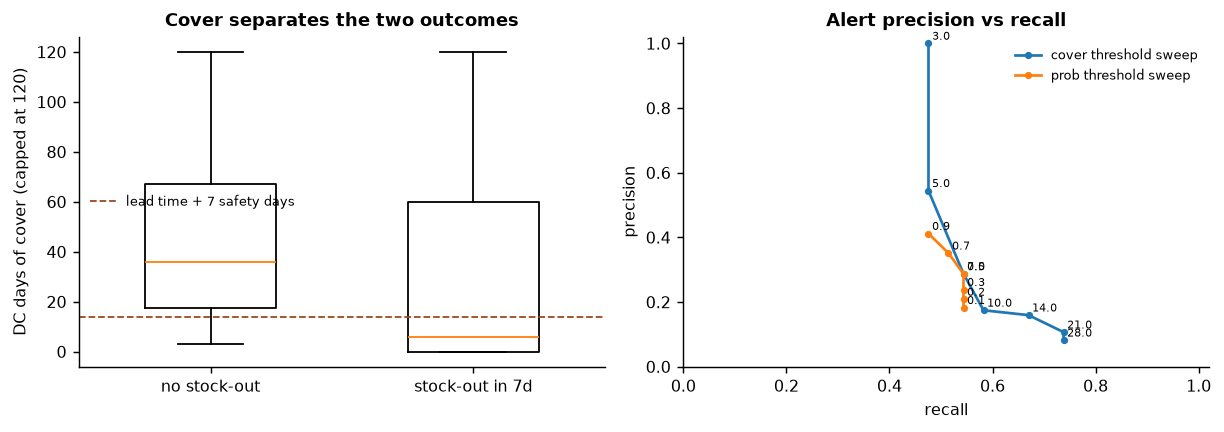

In [5]:
display(pd.read_csv(t / "risk_eval_methods.csv").round(3))
display(pd.read_csv(t / "risk_threshold_sweep.csv").round(3))
display(pd.read_csv(t / "risk_lead_time.csv"))
alerts = pd.read_csv(p.output_dir / f"risk_alerts_{cfg.data.as_of}.csv")
print(alerts["severity"].value_counts())
display(alerts[alerts["severity"] == "high"].head(15).round(2))
show(Image(filename=str(p.figures_dir / "risk_window.png")))

## Supply order

,0
_all,portfolio
n_series,328
order_units,2184400.0
working_capital,53371555.318
expected_lost_units,5255.091
demand_mean_units,4118201.061
ma4_order_units,2156800.0
ma4_working_capital,51918389.858
ma4_expected_lost_units,6341.669
ly_order_units,3434700.0


,cluster,n_series,order_units,working_capital,expected_lost_units,demand_mean_units,ma4_order_units,ma4_working_capital,ma4_expected_lost_units,ly_order_units,ly_working_capital,fq_order_units,fq_working_capital,fq_expected_lost_units,target_stock_value,fq_target_stock_value,lines_below_90,ma4_lines_below_90,fq_lines_below_90,service_level_weighted,ma4_service_level_weighted,fq_service_level_weighted,fill_rate,ma4_fill_rate,fq_fill_rate,delta_working_capital_vs_ma4,lost_units_reduction_vs_ma4,target_stock_value_freed_by_fq
0,A-X,6,0.0,0.000000e+00,10.100,7779.943,0.0,0.000000e+00,10.100,0.0,0.000000e+00,0.0,0.000000e+00,10.100,4.584792e+05,4.533555e+05,0,0,0,0.996,0.996,0.996,0.999,0.999,0.999,0.000,0.000,5123.688
1,A-Y,114,815000.0,1.831785e+07,3943.495,2485496.539,778000.0,1.732297e+07,4469.613,1768300.0,3.765070e+07,598900.0,1.371649e+07,7789.225,7.809658e+07,7.147118e+07,0,5,0,0.990,0.988,0.972,0.998,0.998,0.997,994889.846,526.118,6625396.408
2,A-Z,80,528300.0,1.366857e+07,614.713,636247.864,492500.0,1.271450e+07,1036.270,512500.0,1.184580e+07,305900.0,8.397651e+06,1957.746,2.972149e+07,2.205704e+07,0,2,0,0.997,0.996,0.974,0.999,0.998,0.997,954069.097,421.557,7664451.136
3,B-Y,32,268000.0,6.800557e+06,177.100,330253.399,256800.0,6.374867e+06,557.002,346600.0,8.477955e+06,190500.0,4.870981e+06,2252.152,1.232327e+07,9.944438e+06,0,1,0,0.994,0.987,0.925,0.999,0.998,0.993,425690.329,379.902,2378836.452
4,B-Z,90,397800.0,1.148238e+07,113.398,359984.964,394200.0,1.133646e+07,145.235,400000.0,1.147464e+07,191400.0,5.641031e+06,1781.896,2.072108e+07,1.240010e+07,3,4,3,0.999,0.999,0.935,1.000,1.000,0.995,145921.721,31.837,8320975.180
5,C-Z,6,175300.0,3.102194e+06,396.285,298438.353,235300.0,4.169600e+06,123.449,407300.0,7.219660e+06,48700.0,8.633846e+05,6653.227,1.020468e+07,6.874596e+06,0,0,2,0.993,0.998,0.898,0.999,1.000,0.978,-1067405.534,-272.837,3330081.414


,upc,cedis,cluster,on_hand_projected,demand_p50,demand_p90,safety_stock,order_qty,implied_service_level,working_capital,ma4_order_qty,flags
147,750101310278,CMD2,A-Z,11763.24,83095.50,98885.01,83095.50,154500.0,1.00,2845553.62,140300.0,NaN
228,750101310968,CMD2,B-Y,21469.52,98611.27,123324.21,49305.64,126500.0,0.99,2592609.91,130800.0,NaN
303,750101310694,CMD2,B-Z,9367.22,53093.22,58341.98,53093.22,96900.0,1.00,2181683.48,95400.0,NaN
323,7507891,CMD2,C-Z,96374.87,104361.10,149279.39,104361.10,112400.0,0.99,1994546.49,140500.0,NaN
297,750101310693,CMD2,B-Z,22494.15,51969.23,57743.13,51969.23,81500.0,1.00,1781003.24,83400.0,NaN
68,750101310406,CMD2,A-Y,22964.47,75350.95,87235.53,37675.48,90100.0,1.00,1685924.54,78500.0,NaN
195,750101310546,CMD2,A-Z,8440.32,39918.01,47190.90,39918.01,71400.0,1.00,1680408.53,67100.0,NaN
74,750101310407,CMD2,A-Y,20927.27,58872.14,68805.19,29436.07,67400.0,1.00,1405673.28,59600.0,NaN
201,750101310550,CMD2,B-Y,11354.62,41422.64,49035.90,20711.32,50800.0,1.00,1290574.18,49600.0,NaN
189,750101310541,CMD2,A-Z,1112.07,18188.11,23259.14,18188.11,35300.0,1.00,1276382.31,33300.0,NaN


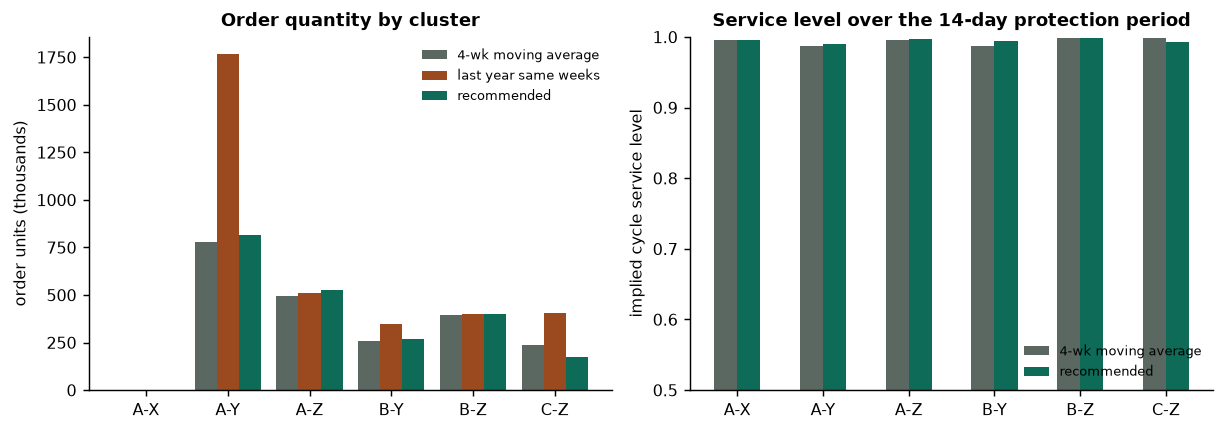

In [6]:
orders = pd.read_csv(p.output_dir / f"supply_order_{cfg.data.as_of}.csv")
display(pd.read_csv(t / "order_summary_portfolio.csv").round(3).T)
display(pd.read_csv(t / "order_summary_cluster.csv").round(3))
display(orders.sort_values("working_capital", ascending=False).head(10)[["upc", "cedis", "cluster", "on_hand_projected", "demand_p50", "demand_p90", "safety_stock", "order_qty", "implied_service_level", "working_capital", "ma4_order_qty", "flags"]].round(2))
show(Image(filename=str(p.figures_dir / "orders_summary.png")))